<a href="https://colab.research.google.com/github/Calebchike/Volve_Production_EDA/blob/main/Volve_Production_EDA_Q%26A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Module**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Import File**

Import Data as df

In [18]:
file_path = "https://github.com/Calebchike/Volve_Production_EDA/raw/eb69a061765c53a95d1f6d811e9d9c522ae902aa/Volve%20production%20data.xlsx"
df = pd.read_excel(file_path)
df.head(5)

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


# **Clean Dataset**

Duplicate Dataframe and make the date column an index


In [19]:
volve = df.copy()
volve['DATEPRD'] = pd.to_datetime(volve['DATEPRD'])
volve = volve.set_index('DATEPRD')

Length of dataframe column before droping columns

In [20]:
len(volve.columns)

23

Drop Columns

In [21]:
columns_to_drop = [
    'NPD_WELL_BORE_NAME',
    'NPD_NPD_WELL_BORE_NAME',
    'NPD_FIELD_CODE',
    'NPD_FIELD_NAME',
    'NPD_FACILITY_CODE',
    'NPD_FACILITY_NAME',
    'WELL_TYPE',
    'AVG_CHOKE_UOM'
]

volve = volve.drop(columns=columns_to_drop)
volve.head(5)

,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
DATEPRD,,,,,,,,,,,,,,,
2014-04-07,15/9-F-1 C,0.0,0.00000,0.00000,0.00000,0.0,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-08,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,1.003059,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-09,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.979008,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-10,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.545759,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-11,15/9-F-1 C,0.0,310.37614,96.87589,277.27826,0.0,1.215987,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production


Length of dataframe column before droping columns

In [22]:
len(volve.columns)

15

Percentage of missing data for each column

In [23]:
missing_data_percentage = (volve.isnull().sum() / len(volve)) * 100
print("Percentage of missing data per column:")
print(missing_data_percentage.sort_values(ascending=False))

Percentage of missing data per column:
BORE_WI_VOL                 63.502622
AVG_ANNULUS_PRESS           49.533069
AVG_CHOKE_SIZE_P            42.951260
AVG_DP_TUBING               42.561085
AVG_DOWNHOLE_TEMPERATURE    42.561085
AVG_DOWNHOLE_PRESSURE       42.561085
AVG_WHT_P                   41.499296
AVG_WHP_P                   41.441730
BORE_GAS_VOL                41.403352
BORE_WAT_VOL                41.403352
BORE_OIL_VOL                41.403352
DP_CHOKE_SIZE                1.880517
ON_STREAM_HRS                1.822950
NPD_WELL_BORE_NAME           0.000000
FLOW_KIND                    0.000000
dtype: float64


Data type of all the column in the dataset

In [24]:
print(volve.dtypes)

NPD_WELL_BORE_NAME           object
ON_STREAM_HRS               float64
AVG_DOWNHOLE_PRESSURE       float64
AVG_DOWNHOLE_TEMPERATURE    float64
AVG_DP_TUBING               float64
AVG_ANNULUS_PRESS           float64
AVG_CHOKE_SIZE_P            float64
AVG_WHP_P                   float64
AVG_WHT_P                   float64
DP_CHOKE_SIZE               float64
BORE_OIL_VOL                float64
BORE_GAS_VOL                float64
BORE_WAT_VOL                float64
BORE_WI_VOL                 float64
FLOW_KIND                    object
dtype: object


# **Dataset Information**

Total data input per flow Kind

In [62]:
volve.groupby(['FLOW_KIND'])['FLOW_KIND'].size().reset_index(name='Count')

,FLOW_KIND,Count
0,injection,6473
1,production,9161


Well Summary

In [64]:
well_summary_df = volve.copy()

# Fill NaN production and on-stream hours with 0 for accurate summation
well_summary_df['BORE_OIL_VOL'] = well_summary_df['BORE_OIL_VOL'].fillna(0)
well_summary_df['BORE_GAS_VOL'] = well_summary_df['BORE_GAS_VOL'].fillna(0)
well_summary_df['BORE_WAT_VOL'] = well_summary_df['BORE_WAT_VOL'].fillna(0)
well_summary_df['ON_STREAM_HRS'] = well_summary_df['ON_STREAM_HRS'].fillna(0)

# Group by well name and flow kind, then aggregate by some chosen metrics
well_data_summary = well_summary_df.groupby(['NPD_WELL_BORE_NAME', 'FLOW_KIND']).agg(
    Total_Data_Entries=('ON_STREAM_HRS', 'size'), # Count of daily entries for each well
    Total_Oil_Production=('BORE_OIL_VOL', 'sum'),
    Total_Gas_Production=('BORE_GAS_VOL', 'sum'),
    Total_Water_Production=('BORE_WAT_VOL', 'sum'),
    Max_Downhole_Pressure=('AVG_DOWNHOLE_PRESSURE', 'max'),
    Min_Downhole_Pressure=('AVG_DOWNHOLE_PRESSURE', 'min'),
    Max_Wellhead_Pressure=('AVG_WHP_P', 'max'),
    Min_Wellhead_Pressure=('AVG_WHP_P', 'min'),
    Total_On_Stream_Hours=('ON_STREAM_HRS', 'sum')
).reset_index()

# Sort by FLOW_KIND in descending order
well_data_summary = well_data_summary.sort_values(by='FLOW_KIND', ascending=False)

# Add a new column for 'Total On-Stream Days'
well_data_summary['Total_On_Stream_Days'] = well_data_summary['Total_On_Stream_Hours'] / 24

# Display the resulting table
print("Well Production and Pressure Summary:")
well_data_summary

Well Production and Pressure Summary:


,NPD_WELL_BORE_NAME,FLOW_KIND,Total_Data_Entries,Total_Oil_Production,Total_Gas_Production,Total_Water_Production,Max_Downhole_Pressure,Min_Downhole_Pressure,Max_Wellhead_Pressure,Min_Wellhead_Pressure,Total_On_Stream_Hours,Total_On_Stream_Days
0,15/9-F-1 C,production,746,177709.33,2.644092e+07,207302.39,313.87058,0.000000,133.59251,0.0,9983.53315,415.980548
1,15/9-F-11,production,1165,1147849.10,1.743105e+08,1090806.27,317.55131,0.000000,114.70830,0.0,26006.21614,1083.592339
2,15/9-F-12,production,3056,4579609.55,6.675423e+08,6833320.37,317.70115,0.000000,137.31103,0.0,65204.06928,2716.836220
3,15/9-F-14,production,3056,3942233.39,5.780095e+08,7121249.74,334.65614,0.000000,125.71857,0.0,62773.67519,2615.569800
4,15/9-F-15 D,production,978,148518.56,2.250535e+07,52366.40,397.58855,193.187243,118.12727,0.0,17824.83278,742.701366
7,15/9-F-5,production,160,41160.68,6.561826e+06,13533.18,NaN,NaN,83.86524,0.0,2973.32502,123.888543
5,15/9-F-4,injection,3327,0.00,0.000000e+00,0.00,NaN,NaN,NaN,NaN,64267.16117,2677.798382
6,15/9-F-5,injection,3146,0.00,0.000000e+00,0.00,NaN,NaN,NaN,NaN,57856.52806,2410.688669


# **Production Trends & Decline**

## How does oil rate change over each well's life? Where does the decline start?

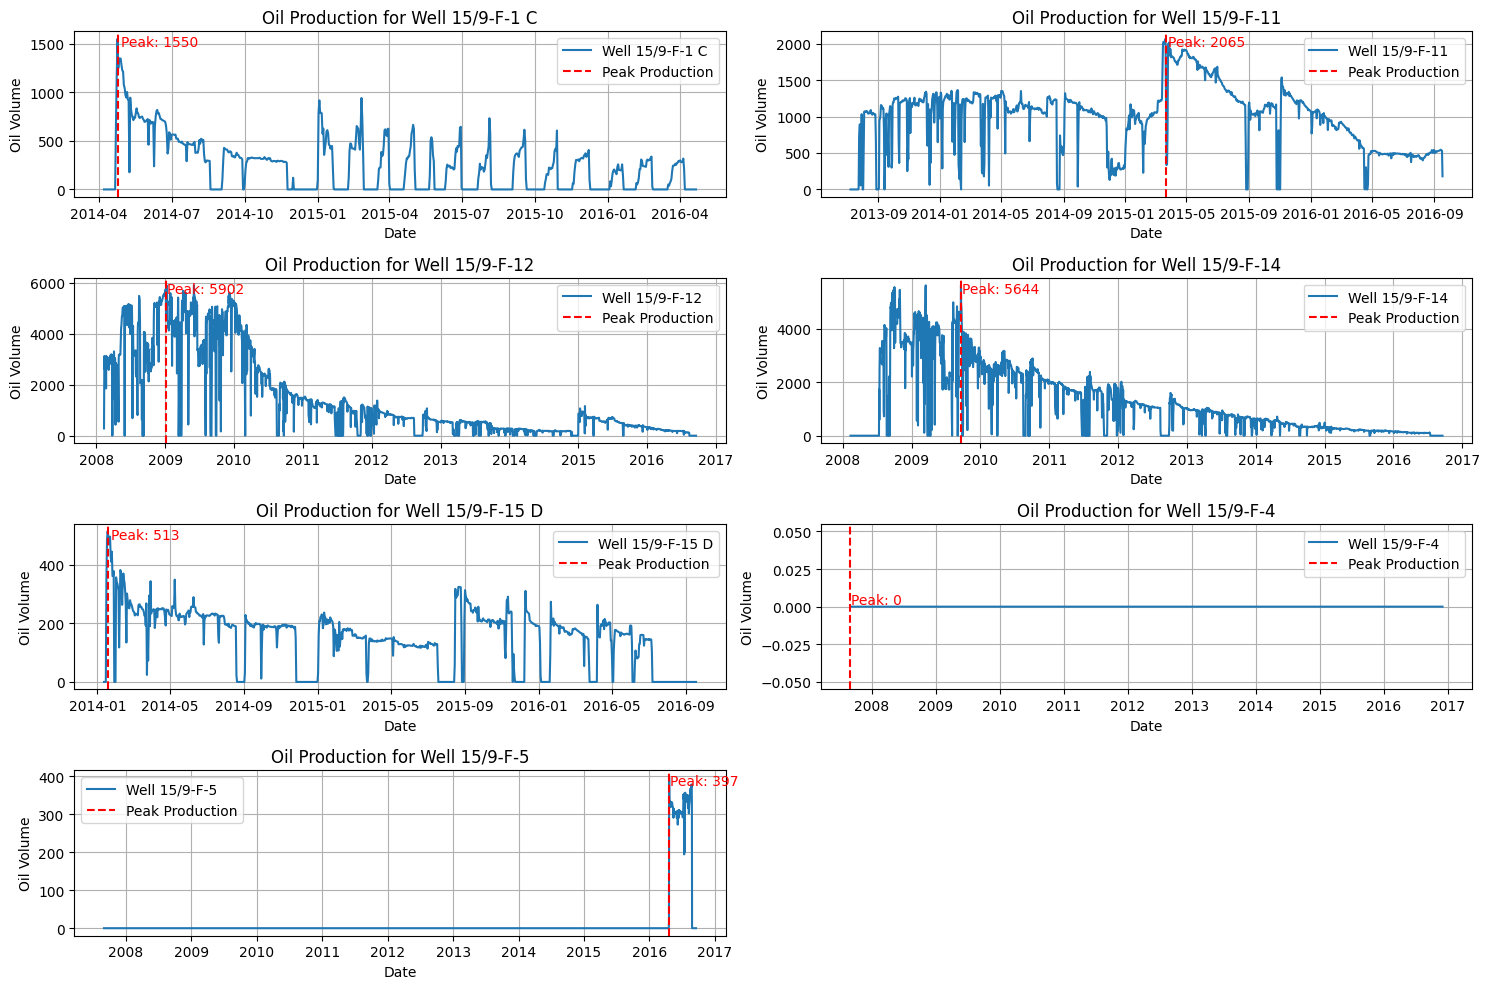

In [65]:
# Group by well and date, then sum the oil volume
well_production = volve.groupby(['NPD_WELL_BORE_NAME', 'DATEPRD'])['BORE_OIL_VOL'].sum().reset_index()

# Get unique well bore codes
well_codes = well_production['NPD_WELL_BORE_NAME'].unique()

plt.figure(figsize=(15, 10))

for i, well in enumerate(well_codes):
    well_data = well_production[well_production['NPD_WELL_BORE_NAME'] == well]

    # Sort by date to ensure correct plotting
    well_data = well_data.sort_values(by='DATEPRD')

    plt.subplot(len(well_codes) // 2 + 1, 2, i + 1)  # Adjust subplot grid as needed
    plt.plot(well_data['DATEPRD'], well_data['BORE_OIL_VOL'], label=f'Well {well}')

    # Find the peak production to indicate decline start
    max_prod_date = well_data.loc[well_data['BORE_OIL_VOL'].idxmax()]['DATEPRD']
    max_prod_value = well_data['BORE_OIL_VOL'].max()

    plt.axvline(x=max_prod_date, color='r', linestyle='--', label='Peak Production')
    plt.text(max_prod_date + pd.Timedelta(days=5), max_prod_value * 0.93, f'Peak: {max_prod_value:.0f}', rotation=0, va='bottom', ha='left', color='red')

    plt.title(f'Oil Production for Well {well}')
    plt.xlabel('Date')
    plt.ylabel('Oil Volume')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

plt.tight_layout()
plt.show()


## Which wells gave the most cumulative oil? Which gave the least, and why?

The well `'15/9-F-4'` has the least oil production (0.00) because it is classified as an **injection well**, not a production well, as observed in the `FLOW_KIND` column. Injection wells are used to inject fluids into the reservoir to maintain pressure or sweep oil towards production wells, not to produce oil themselves. The well `'15/9-F-5'` has very low cumulative oil production, indicating minimal or intermittent oil production during the observed period.

In [74]:
# Create a copy of the main DataFrame to work with all wells
all_wells_df = volve.copy()

# Fill NaN in BORE_OIL_VOL with 0 before calculating cumulative sum for all wells
all_wells_df['BORE_OIL_VOL'] = all_wells_df['BORE_OIL_VOL'].fillna(0)

# Calculate cumulative oil production for each well (including injection wells)
cumulative_oil_all_wells = all_wells_df.groupby('NPD_WELL_BORE_NAME')['BORE_OIL_VOL'].sum().sort_values(ascending=False)

print(f"Number of unique wells (including production and injection): {cumulative_oil_all_wells.nunique()}")
cumulative_oil_all_wells

print("------Wells with the Most Cumulative Oil Production (All Wells)------")
print(f"{cumulative_oil_all_wells.head(5)}")
print("\n")
print("------Wells with the Least Cumulative Oil Production (All Wells)------")
print(f"{cumulative_oil_all_wells.tail(2)}")

Number of unique wells (including production and injection): 7
------Wells with the Most Cumulative Oil Production (All Wells)------
NPD_WELL_BORE_NAME
15/9-F-12      4579609.55
15/9-F-14      3942233.39
15/9-F-11      1147849.10
15/9-F-1 C      177709.33
15/9-F-15 D     148518.56
Name: BORE_OIL_VOL, dtype: float64


------Wells with the Least Cumulative Oil Production (All Wells)------
NPD_WELL_BORE_NAME
15/9-F-5    41160.68
15/9-F-4        0.00
Name: BORE_OIL_VOL, dtype: float64


## Does production drop in clear stages, or fade slow and steady?